<table style="width:100%;">
  <tr>
    <td style="text-align: left; vertical-align: middle;">
      <h2>Ciência de Dados</h2>
      <p>
        Prof. Túlio Ribeiro<br>
        <br>
        Núcleo de Ciência de Dados e Inteligência Artificial (NCDIA)<br>
        <br>
        Universidade de Fortaleza
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle;">
      <img src="https://www.unifor.br/o/unifor-theme/images/unifor-logo-horizontal.svg" width="200px">
    </td>
  </tr>
</table>


# Estatística Descritiva

Nesta aula, usamos partidas das **Copas do Mundo masculinas de 1930 a 2022** para resumir uma variável sem perder seu contexto.

Ao final, você deverá saber:

- interpretar uma tabela e reconhecer sua unidade de análise;
- calcular medidas de centralidade e de dispersão;
- comparar média simples e média ponderada;
- interpretar quartis, percentis, IIQ e boxplot.


## Dados e proveniência

Cada linha representa uma partida internacional. Usaremos apenas os jogos cuja competição é `FIFA World Cup`, até 2022.

Fonte: [International Football Results](https://github.com/martj42/international_results/tree/394fe81893b062fbc2cf6257e988ac7cc4c039a1), disponibilizado em **CC0**. O endereço do CSV está fixado em um commit para que a aula use sempre a mesma versão.


### Dicionário de dados

| Coluna | Origem | Significado |
|---|---|---|
| `data` | arquivo | data da partida |
| `mandante` | arquivo | seleção indicada como mandante |
| `visitante` | arquivo | seleção indicada como visitante |
| `gols_mandante` | arquivo | gols marcados pelo mandante |
| `gols_visitante` | arquivo | gols marcados pelo visitante |
| `competicao` | arquivo | nome da competição |
| `cidade` | arquivo | cidade da partida |
| `pais` | arquivo | país onde a partida ocorreu |
| `campo_neutro` | arquivo | indica se o local era neutro para o mandante |
| `edicao` | derivada | ano da Copa do Mundo |
| `total_gols` | derivada | soma dos gols das duas seleções |
| `saldo_gols` | derivada | gols do mandante menos gols do visitante |
| `resultado` | derivada | vitória do mandante, empate ou vitória do visitante |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import t, trim_mean

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 15)

AZUL = "#0B5FA5"
LARANJA = "#F28E2B"


In [ ]:
URL_RESULTADOS = (
    "https://raw.githubusercontent.com/martj42/international_results/"
    "394fe81893b062fbc2cf6257e988ac7cc4c039a1/results.csv"
)

nomes_colunas = {
    "date": "data",
    "home_team": "mandante",
    "away_team": "visitante",
    "home_score": "gols_mandante",
    "away_score": "gols_visitante",
    "tournament": "competicao",
    "city": "cidade",
    "country": "pais",
    "neutral": "campo_neutro",
}

partidas = pd.read_csv(URL_RESULTADOS, parse_dates=["date"]).rename(columns=nomes_colunas)


In [ ]:
partidas.tail()

,data,mandante,visitante,gols_mandante,gols_visitante,competicao,cidade,pais,campo_neutro
49542,2026-08-16,Malaysia,Vietnam,0,2,ASEAN Championship,Kuala Lumpur,Malaysia,False
49543,2026-08-18,Thailand,Singapore,1,2,ASEAN Championship,Bangkok,Thailand,False
49544,2026-08-19,Vietnam,Malaysia,2,0,ASEAN Championship,Hanoi,Vietnam,False
49545,2026-08-22,Thailand,Vietnam,0,2,ASEAN Championship,Bangkok,Thailand,False
49546,2026-08-26,Vietnam,Thailand,2,2,ASEAN Championship,Hanoi,Vietnam,False


In [ ]:
partidas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49547 entries, 0 to 49546
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            49547 non-null  datetime64[ns]
 1   mandante        49547 non-null  object        
 2   visitante       49547 non-null  object        
 3   gols_mandante   49547 non-null  int64         
 4   gols_visitante  49547 non-null  int64         
 5   competicao      49547 non-null  object        
 6   cidade          49547 non-null  object        
 7   pais            49547 non-null  object        
 8   campo_neutro    49547 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(5)
memory usage: 3.1+ MB


In [ ]:
partidas['competicao'].unique()

array(['Friendly', 'British Home Championship', 'Évence Coppée Trophy',
       'Muratti Vase', 'Copa Lipton', 'Copa Newton',
       'Copa Premio Honor Argentino', 'Olympic Games',
       'Copa Premio Honor Uruguayo', 'Far Eastern Championship Games',
       'Copa Roca', 'Copa América', 'Inter-Allied Games', 'Peace Cup',
       'Open International Championship', 'Soccer Ashes',
       'Copa Chevallier Boutell', 'Nordic Championship',
       'Central European International Cup', 'Baltic Cup', 'Balkan Cup',
       'Central American and Caribbean Games', 'FIFA World Cup',
       'Copa Rio Branco', 'FIFA World Cup qualification',
       'Bolivarian Games', 'CCCF Championship', 'NAFC Championship',
       'Copa Oswaldo Cruz', 'Asian Games', 'Pan American Championship',
       'Copa del Pacífico', "Copa Bernardo O'Higgins",
       'AFC Asian Cup qualification', 'Atlantic Cup', 'AFC Asian Cup',
       'African Cup of Nations', 'Copa Paz del Chaco',
       'Merdeka Tournament', 'UEFA Euro quali

In [ ]:
# Seleciona somente partidas de Copa do Mundo realizadas até 2022.
copa = partidas.loc[
    (partidas["competicao"] == "FIFA World Cup")
    & (partidas["data"].dt.year <= 2026)
].copy()

# Cria as quatro variáveis que serão usadas na análise.
copa["edicao"] = copa["data"].dt.year
copa["total_gols"] = copa["gols_mandante"] + copa["gols_visitante"]
copa["saldo_gols"] = copa["gols_mandante"] - copa["gols_visitante"]
copa["resultado"] = np.select(
    [copa["saldo_gols"] > 0, copa["saldo_gols"] < 0],
    ["Vitória do mandante", "Vitória do visitante"],
    default="Empate",
)


In [ ]:
copa.shape


(1068, 13)

In [ ]:
copa.tail()


,data,mandante,visitante,gols_mandante,gols_visitante,competicao,cidade,pais,campo_neutro,edicao,total_gols,saldo_gols,resultado
49515,2026-07-11,Argentina,Switzerland,3,1,FIFA World Cup,Kansas City,United States,True,2026,4,2,Vitória do mandante
49516,2026-07-14,France,Spain,0,2,FIFA World Cup,Arlington,United States,True,2026,2,-2,Vitória do visitante
49517,2026-07-15,England,Argentina,1,2,FIFA World Cup,Atlanta,United States,True,2026,3,-1,Vitória do visitante
49518,2026-07-18,France,England,4,6,FIFA World Cup,Miami Gardens,United States,True,2026,10,-2,Vitória do visitante
49520,2026-07-19,Spain,Argentina,1,0,FIFA World Cup,East Rutherford,United States,True,2026,1,1,Vitória do mandante


In [ ]:
copa['resultado'].value_counts()

,count
resultado,
Vitória do mandante,488
Vitória do visitante,342
Empate,238


## Visão inicial

Antes de calcular uma medida, observamos a escala, a frequência dos valores e possíveis diferenças entre edições. Isso evita resumir a variável sem entender sua forma.


In [ ]:
colunas_numericas = ["gols_mandante", "gols_visitante", "total_gols", "saldo_gols"]

copa[colunas_numericas].describe().round(2)


,gols_mandante,gols_visitante,total_gols,saldo_gols
count,1068.00,1068.00,1068.00,1068.00
mean,1.58,1.25,2.84,0.33
std,1.49,1.29,1.92,2.03
min,0.00,0.00,0.00,-8.00
25%,0.75,0.00,1.00,-1.00
50%,1.00,1.00,3.00,0.00
75%,2.00,2.00,4.00,1.00
max,10.00,8.00,12.00,9.00


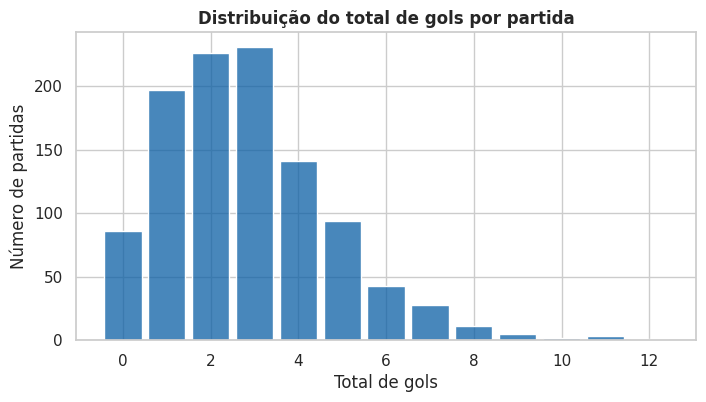

In [ ]:
ax = sns.histplot(
    data=copa,
    x="total_gols",
    discrete=True,
    color=AZUL,
    shrink=0.85,
)
ax.set(
    title="Distribuição do total de gols por partida",
    xlabel="Total de gols",
    ylabel="Número de partidas",
)
plt.show()


**Figura 1 — Frequência do total de gols.** A maior parte das partidas teve poucos gols, enquanto totais altos aparecem com menor frequência. A cauda à direita pode influenciar medidas que usam todos os valores.


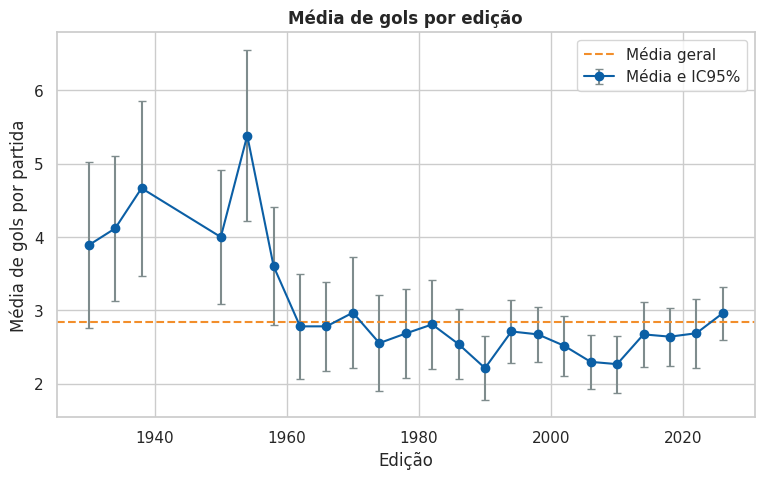

In [ ]:
gols_por_edicao = (
    copa.groupby("edicao", as_index=False)
    .agg(
        media_gols=("total_gols", "mean"),
        desvio_gols=("total_gols", "std"),
        partidas=("total_gols", "size"),
    )
)

# Calcula o intervalo de confiança de 95% da média.
gols_por_edicao["erro_padrao"] = (
    gols_por_edicao["desvio_gols"]
    / np.sqrt(gols_por_edicao["partidas"])
)

gols_por_edicao["margem_ic95"] = (
    t.ppf(
        0.975,
        df=gols_por_edicao["partidas"] - 1,
    )
    * gols_por_edicao["erro_padrao"]
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(
    gols_por_edicao["edicao"],
    gols_por_edicao["media_gols"],
    yerr=gols_por_edicao["margem_ic95"],
    fmt="o-",
    color=AZUL,
    ecolor="#7F8C8D",
    capsize=3,
    label="Média e IC95%",
)

ax.axhline(
    copa["total_gols"].mean(),
    color=LARANJA,
    linestyle="--",
    label="Média geral",
)

ax.set(
    title="Média de gols por edição",
    xlabel="Edição",
    ylabel="Média de gols por partida",
)

ax.legend()
plt.show()

**Figura 2 — Evolução da média de gols.** As primeiras edições tiveram médias mais altas. A linha tracejada representa a média das 964 partidas, e não a média simples entre as edições.


## Medidas de centralidade

Medidas de centralidade representam um valor típico da distribuição. Para valores $x_1,\ldots,x_n$:

- **Média:** $\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i$. Usa todos os valores e é sensível às caudas.
- **Mediana:** valor que separa os dados ordenados em duas metades. É menos influenciada por valores extremos.
- **Moda:** $\operatorname{Mo}=\arg\max_x f(x)$. Indica o valor mais frequente e pode haver mais de uma moda.
- **Média aparada:** remove a mesma proporção das duas caudas antes de calcular a média. Com $k=\lfloor0{,}10n\rfloor$, $\bar{x}_{10\%}=\frac{1}{n-2k}\sum_{i=k+1}^{n-k}x_{(i)}$.


In [ ]:
gols = copa["total_gols"]

medidas_centralidade = pd.DataFrame({
    "Medida": ["Média", "Mediana", "Moda", "Média aparada (10% em cada cauda)"],
    "Total de gols": [
        gols.mean(),
        gols.median(),
        gols.mode().iloc[0],
        trim_mean(gols, 0.10),
    ],
})

medidas_centralidade.round(2)


,Medida,Total de gols
0,Média,2.84
1,Mediana,3.00
2,Moda,3.00
3,Média aparada (10% em cada cauda),2.68


A média é aproximadamente **2,82 gols**, enquanto a média aparada é menor. A diferença indica a influência das partidas com muitos gols. Mediana e moda iguais a **3** mostram que esse é um valor representativo neste recorte.


### Média ponderada

Usamos pesos quando as observações resumidas representam quantidades diferentes de unidades:

$$\bar{x}_w=\frac{\sum_i w_i x_i}{\sum_i w_i}.$$

Aqui, $x_i$ é a média de gols da edição e $w_i$ é seu número de partidas. Sem os pesos, uma edição com 17 jogos teria a mesma importância de outra com 64.


In [ ]:
media_simples_edicoes = gols_por_edicao["media_gols"].mean()
media_ponderada_edicoes = np.average(
    gols_por_edicao["media_gols"],
    weights=gols_por_edicao["partidas"],
)

comparacao_medias = pd.DataFrame({
    "Cálculo": [
        "Média simples entre as edições",
        "Média das edições ponderada pelo número de partidas",
        "Média calculada diretamente nas partidas",
    ],
    "Gols por partida": [
        media_simples_edicoes,
        media_ponderada_edicoes,
        gols.mean(),
    ],
})

comparacao_medias.round(2)


,Cálculo,Gols por partida
0,Média simples entre as edições,3.06
1,Média das edições ponderada pelo número de par...,2.84
2,Média calculada diretamente nas partidas,2.84


A média simples entre edições é maior porque as Copas antigas tiveram poucos jogos e muitos gols. Ao ponderar pelo número de partidas, o resultado coincide com a média calculada diretamente nas 964 partidas.


## Medidas de dispersão

Dispersão descreve quanto os valores variam:

- **Amplitude:** $\max(x)-\min(x)$; depende apenas dos dois extremos.
- **Variância populacional:** $\sigma^2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^2$; sua unidade fica ao quadrado.
- **Desvio-padrão:** $\sigma=\sqrt{\sigma^2}$; permanece na unidade original.

Como estamos descrevendo todas as partidas do recorte, usamos `ddof=0`. Para estimar a partir de uma amostra, costuma-se usar `ddof=1`.


In [ ]:
medidas_dispersao = pd.DataFrame({
    "Medida": [
        "Mínimo",
        "Máximo",
        "Amplitude",
        "Variância populacional",
        "Desvio-padrão populacional",
    ],
    "Resultado": [
        gols.min(),
        gols.max(),
        gols.max() - gols.min(),
        gols.var(ddof=0),
        gols.std(ddof=0),
    ],
    "Unidade": ["gols", "gols", "gols", "gols²", "gols"],
})

medidas_dispersao.round(2)


,Medida,Resultado,Unidade
0,Mínimo,0.00,gols
1,Máximo,12.00,gols
2,Amplitude,12.00,gols
3,Variância populacional,3.69,gols²
4,Desvio-padrão populacional,1.92,gols


O total varia de **0 a 12 gols**, portanto a amplitude é 12. O desvio-padrão de aproximadamente **1,93 gol** resume a variabilidade usando todas as partidas; ele não significa "distância média" até a média.


## Quartis, percentis e intervalo interquartil

O percentil $P_p$ deixa aproximadamente $p\%$ dos valores abaixo ou iguais a ele. Os quartis são $Q_1=P_{25}$, $Q_2=P_{50}$ e $Q_3=P_{75}$.

O **intervalo interquartil (IIQ)** é $Q_3-Q_1$ e mede a largura da metade central dos dados. Percentis são úteis para localizar uma observação na distribuição, mas o resultado pode depender do método de interpolação.


In [ ]:
percentis = gols.quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95])

tabela_percentis = pd.DataFrame({
    "Medida": ["P10", "Q1 (P25)", "Q2 (P50)", "Q3 (P75)", "P90", "P95", "IIQ"],
    "Total de gols": [
        percentis.loc[0.10],
        percentis.loc[0.25],
        percentis.loc[0.50],
        percentis.loc[0.75],
        percentis.loc[0.90],
        percentis.loc[0.95],
        percentis.loc[0.75] - percentis.loc[0.25],
    ],
})

tabela_percentis.round(2)


,Medida,Total de gols
0,P10,1.0
1,Q1 (P25),1.0
2,Q2 (P50),3.0
3,Q3 (P75),4.0
4,P90,5.0
5,P95,6.0
6,IIQ,3.0


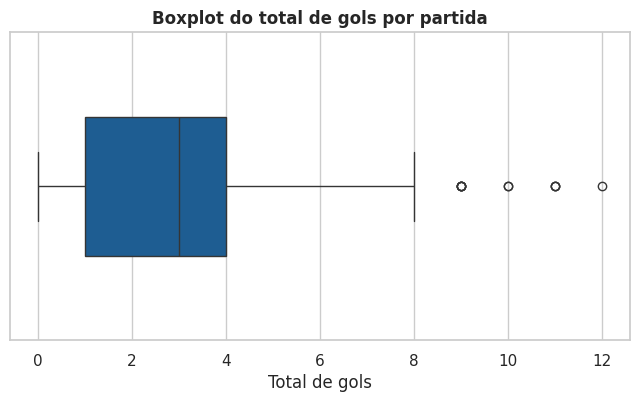

In [ ]:
ax = sns.boxplot(
    data=copa,
    x="total_gols",
    color=AZUL,
    width=0.45,
)
ax.set(
    title="Boxplot do total de gols por partida",
    xlabel="Total de gols",
)
plt.show()


**Figura 3 — Boxplot do total de gols.** A caixa vai de **1 a 4 gols** ($Q_1$ a $Q_3$), a linha interna marca a mediana de **3 gols** e os bigodes seguem a regra de $1{,}5\times IIQ$. Pontos além dos bigodes são partidas incomuns, mas não devem ser tratados automaticamente como erros.


## Resumo

| Medida | Quando usar | Código | Cuidado |
|---|---|---|---|
| Média | resumir valores numéricos usando todas as observações | `s.mean()` | é influenciada pelas caudas |
| Mediana | buscar uma centralidade resistente | `s.median()` | não considera as distâncias entre valores |
| Moda | identificar o valor mais frequente | `s.mode()` | pode haver nenhuma moda única |
| Média aparada | reduzir a influência das caudas | `trim_mean(s, 0.10)` | descarta parte dos dados |
| Média ponderada | combinar grupos de tamanhos diferentes | `np.average(x, weights=w)` | os pesos precisam representar o problema |
| Amplitude | comunicar rapidamente a extensão total | `s.max() - s.min()` | usa somente os extremos |
| Variância | quantificar desvios quadráticos | `s.var(ddof=0)` | fica na unidade ao quadrado |
| Desvio-padrão | expressar dispersão na unidade original | `s.std(ddof=0)` | não é a distância média |
| Quartis e percentis | localizar valores na distribuição | `s.quantile(p)` | declarar o percentil usado |
| IIQ | medir a largura da metade central | `Q3 - Q1` | não descreve as caudas |
| Boxplot | comparar mediana, IIQ e valores distantes | `sns.boxplot(x=s)` | um ponto distante não é necessariamente erro |


## Exercícios

1. Calcule as quatro medidas de centralidade para `gols_mandante`. O que muda em relação a `total_gols`?
2. Encontre $P_{75}$ e $P_{90}$ de `total_gols` e interprete os dois valores em palavras.
3. Compare a amplitude e o IIQ de `saldo_gols`. Qual medida é mais sensível a partidas com placares muito diferentes?
4. Calcule a média de gols de cada edição desde 1990. Compare a média simples e a ponderada.
5. Construa um boxplot de `gols_mandante` e descreva mediana, caixa, bigodes e pontos distantes.
